In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Import loader functions
from loader_ir import (
    load_all_ir_data,
    print_data_summary,
    baseline_correction,
    apply_baseline_correction,
    PLASTIC_TYPES,
    CONTAMINANTS
)

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
%matplotlib inline

print("Libraries loaded successfully!")

Libraries loaded successfully!


## 1. Data Loading & Overview

In [2]:
# Define data path
script_dir = Path('.').resolve()
project_root = script_dir.parent.parent
raw_data_dir = project_root / 'data' / 'flattened_IR_data' / 'raw'

print(f"Loading data from: {raw_data_dir}")
print()

# Load all IR data
data = load_all_ir_data(str(raw_data_dir), verbose=True)

Loading data from: C:\Users\Mikey\Desktop\PhD writings\AI washing\AI-edited program file\data\flattened_IR_data\raw

Found 788 CSV files in C:\Users\Mikey\Desktop\PhD writings\AI washing\AI-edited program file\data\flattened_IR_data\raw

Wavenumber resolution distribution:
  - 7469 points: 532 files (reference)
  - 1869 points: 256 files

Reference wavenumber range: 399.7 - 4000.2 cm^-1
Number of wavenumber points: 7469

Successfully loaded 788 spectra
Interpolated 256 files to match reference resolution (7469 points)


In [3]:
# Extract key arrays
wavenumbers = data['wavenumbers']
spectra = data['spectra']
plastic_labels = data['plastic_labels']
contaminant_labels = data['contaminant_labels']
filenames = data['filenames']
plastic_types = data['plastic_types']
contaminants_list = data['contaminants_list']

# Print data summary
print_data_summary(data)


DATA SUMMARY

Spectral Data:
  - Number of samples: 788
  - Number of wavenumber points: 7469
  - Wavenumber range: 399.7 - 4000.2 cm^-1

Plastic Type Distribution:
  - PP: 172 samples
  - LDPE: 188 samples
  - LLDPE: 190 samples
  - HDPE: 238 samples

Contaminant Distribution:
  - BSA: 404 samples
  - Oil: 418 samples
  - Starch: 360 samples
  - CMC: 314 samples
  - Guar: 400 samples
  - Casein: 30 samples

Samples by number of contaminants:
  - 0 contaminants: 90 samples
  - 1 contaminants: 128 samples
  - 2 contaminants: 224 samples
  - 3 contaminants: 104 samples
  - 4 contaminants: 172 samples
  - 5 contaminants: 70 samples



In [4]:
# Create a summary DataFrame for analysis
df = pd.DataFrame({
    'filename': filenames,
    'plastic_type': plastic_types,
    'n_contaminants': contaminant_labels.sum(axis=1).astype(int),
    'contaminants': [', '.join(c) if c else 'None' for c in contaminants_list],
    'mean_absorbance': spectra.mean(axis=1),
    'max_absorbance': spectra.max(axis=1),
    'min_absorbance': spectra.min(axis=1),
    'std_absorbance': spectra.std(axis=1),
    'range_absorbance': spectra.max(axis=1) - spectra.min(axis=1)
})

# Add individual contaminant columns
for i, cont in enumerate(CONTAMINANTS):
    df[f'has_{cont}'] = contaminant_labels[:, i].astype(int)

print(f"DataFrame shape: {df.shape}")
df.head(10)

DataFrame shape: (788, 15)


,filename,plastic_type,n_contaminants,contaminants,mean_absorbance,max_absorbance,min_absorbance,std_absorbance,range_absorbance,has_BSA,has_Oil,has_Starch,has_CMC,has_Guar,has_Casein
0,1203-54-2 pp-1.CSV,PP,0,None,0.035095,0.747256,-0.006746,0.074623,0.754003,0,0,0,0,0,0
1,1203-54-2 pp-2.CSV,PP,0,None,0.039203,0.717296,-0.006417,0.071891,0.723714,0,0,0,0,0,0
2,1203-54-3 LDPE-1.CSV,LDPE,0,None,0.107521,0.509622,-0.002764,0.112191,0.512386,0,0,0,0,0,0
3,1203-54-3 LDPE-2.CSV,LDPE,0,None,0.116980,0.471779,0.001019,0.121806,0.470760,0,0,0,0,0,0
4,1203-54-3 LDPE-3.CSV,LDPE,0,None,0.108749,0.523525,-0.001594,0.111512,0.525119,0,0,0,0,0,0
5,1203-54-3 LDPE-4.CSV,LDPE,0,None,0.112968,0.510607,-0.001091,0.116500,0.511698,0,0,0,0,0,0
6,1203-54-4 LLDPE-1.CSV,LLDPE,0,None,0.077909,0.807221,0.002845,0.093882,0.804376,0,0,0,0,0,0
7,1203-54-4 LLDPE-2.CSV,LLDPE,0,None,0.112188,0.452762,0.003778,0.113439,0.448984,0,0,0,0,0,0
8,1203-54-5 LLDPE-1.CSV,LLDPE,0,None,0.109634,0.457268,0.004864,0.111676,0.452405,0,0,0,0,0,0
9,1203-54-5 LLDPE-2.CSV,LLDPE,0,None,0.120990,0.490031,0.003434,0.123132,0.486597,0,0,0,0,0,0


## 2. Spectral Statistics

In [5]:
# Overall spectral statistics
print("=" * 60)
print("OVERALL SPECTRAL STATISTICS")
print("=" * 60)
print(f"\nDataset dimensions:")
print(f"  - Number of samples: {spectra.shape[0]}")
print(f"  - Wavenumber points: {spectra.shape[1]}")
print(f"  - Wavenumber range: {wavenumbers.min():.1f} - {wavenumbers.max():.1f} cm⁻¹")
print(f"  - Wavenumber resolution: {np.mean(np.abs(np.diff(wavenumbers))):.2f} cm⁻¹")

print(f"\nAbsorbance statistics:")
print(f"  - Global min: {spectra.min():.6f}")
print(f"  - Global max: {spectra.max():.6f}")
print(f"  - Global mean: {spectra.mean():.6f}")
print(f"  - Global std: {spectra.std():.6f}")

OVERALL SPECTRAL STATISTICS

Dataset dimensions:
  - Number of samples: 788
  - Wavenumber points: 7469
  - Wavenumber range: 399.7 - 4000.2 cm⁻¹
  - Wavenumber resolution: 0.48 cm⁻¹

Absorbance statistics:
  - Global min: -0.031580
  - Global max: 1.472108
  - Global mean: 0.089083
  - Global std: 0.106385


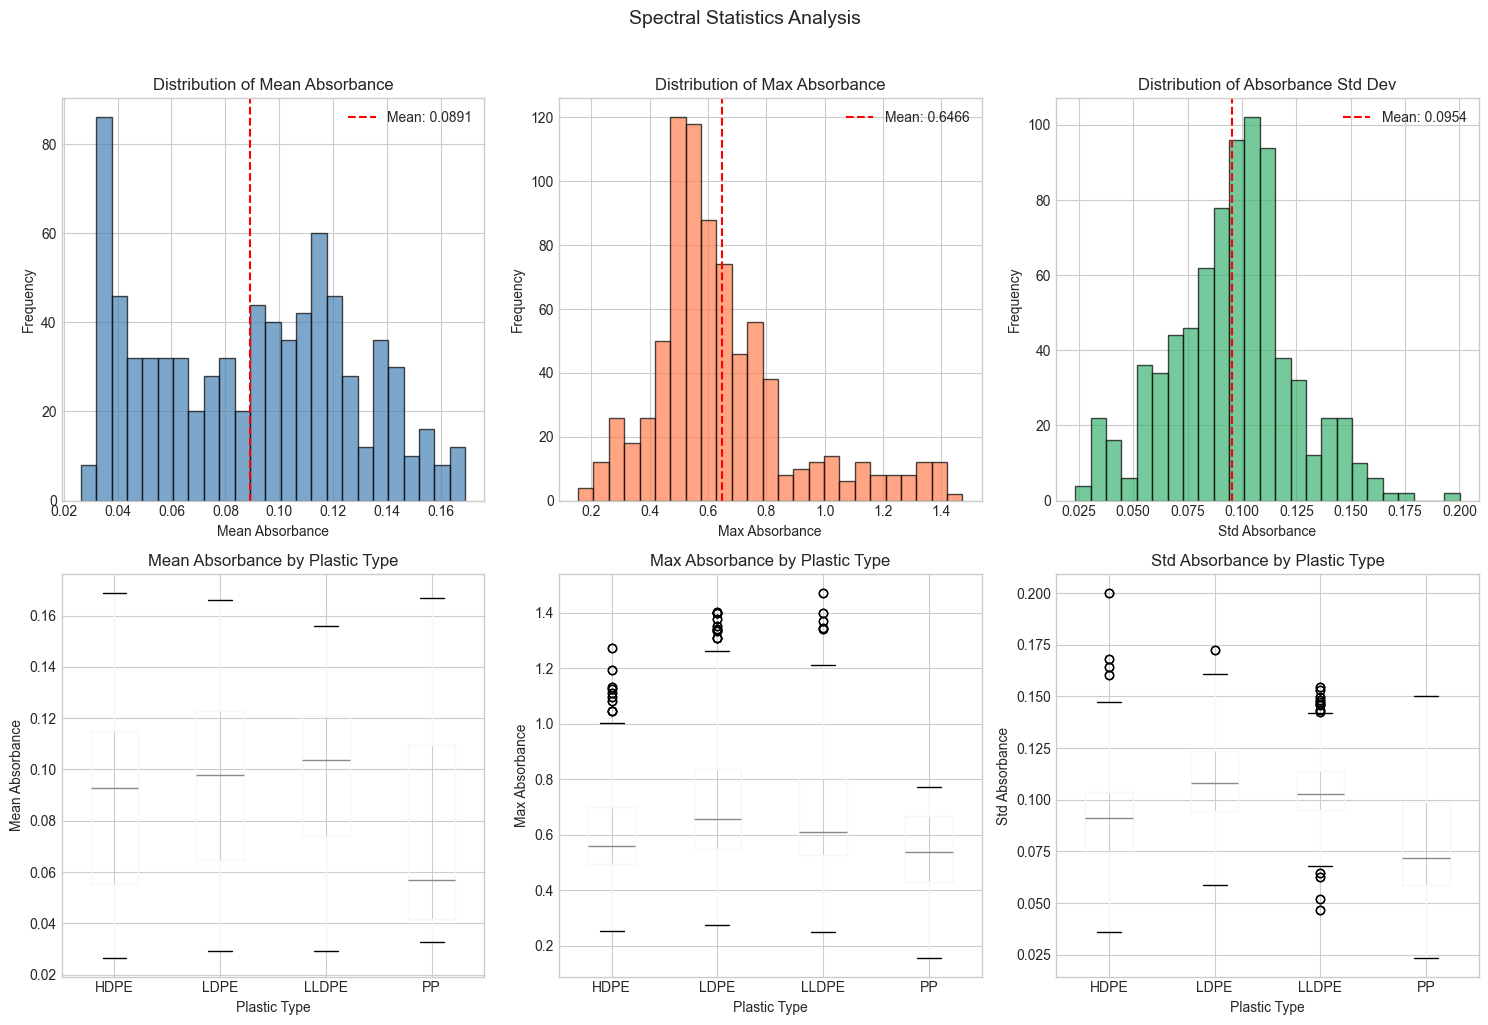

In [6]:
# Per-sample statistics distribution
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Mean absorbance distribution
axes[0, 0].hist(df['mean_absorbance'], bins=25, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].axvline(df['mean_absorbance'].mean(), color='red', linestyle='--', label=f'Mean: {df["mean_absorbance"].mean():.4f}')
axes[0, 0].set_xlabel('Mean Absorbance')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of Mean Absorbance')
axes[0, 0].legend()

# Max absorbance distribution
axes[0, 1].hist(df['max_absorbance'], bins=25, color='coral', edgecolor='black', alpha=0.7)
axes[0, 1].axvline(df['max_absorbance'].mean(), color='red', linestyle='--', label=f'Mean: {df["max_absorbance"].mean():.4f}')
axes[0, 1].set_xlabel('Max Absorbance')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Distribution of Max Absorbance')
axes[0, 1].legend()

# Std absorbance distribution
axes[0, 2].hist(df['std_absorbance'], bins=25, color='mediumseagreen', edgecolor='black', alpha=0.7)
axes[0, 2].axvline(df['std_absorbance'].mean(), color='red', linestyle='--', label=f'Mean: {df["std_absorbance"].mean():.4f}')
axes[0, 2].set_xlabel('Std Absorbance')
axes[0, 2].set_ylabel('Frequency')
axes[0, 2].set_title('Distribution of Absorbance Std Dev')
axes[0, 2].legend()

# Box plots by plastic type
df.boxplot(column='mean_absorbance', by='plastic_type', ax=axes[1, 0])
axes[1, 0].set_xlabel('Plastic Type')
axes[1, 0].set_ylabel('Mean Absorbance')
axes[1, 0].set_title('Mean Absorbance by Plastic Type')

df.boxplot(column='max_absorbance', by='plastic_type', ax=axes[1, 1])
axes[1, 1].set_xlabel('Plastic Type')
axes[1, 1].set_ylabel('Max Absorbance')
axes[1, 1].set_title('Max Absorbance by Plastic Type')

df.boxplot(column='std_absorbance', by='plastic_type', ax=axes[1, 2])
axes[1, 2].set_xlabel('Plastic Type')
axes[1, 2].set_ylabel('Std Absorbance')
axes[1, 2].set_title('Std Absorbance by Plastic Type')

plt.suptitle('Spectral Statistics Analysis', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 3. Label Distribution Analysis

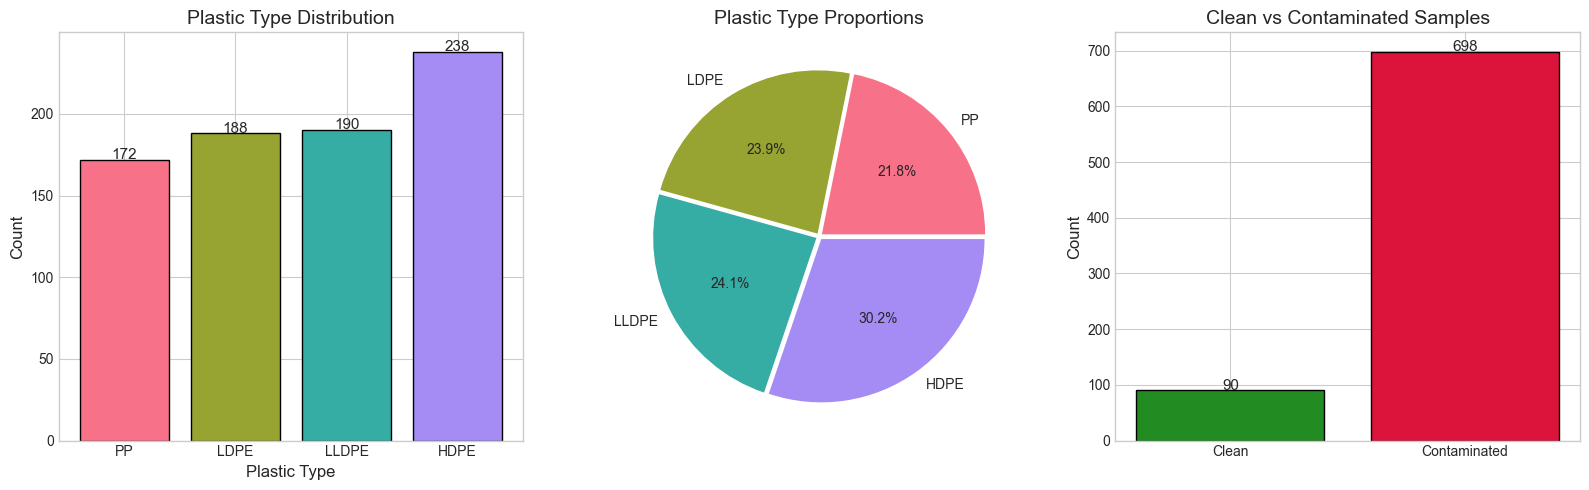

In [7]:
# Plastic type distribution
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Bar chart
plastic_counts = df['plastic_type'].value_counts().reindex(PLASTIC_TYPES)
colors = sns.color_palette('husl', len(PLASTIC_TYPES))
bars = axes[0].bar(PLASTIC_TYPES, plastic_counts.values, color=colors, edgecolor='black')
axes[0].set_xlabel('Plastic Type', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_title('Plastic Type Distribution', fontsize=14)
for bar, count in zip(bars, plastic_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
                 str(count), ha='center', fontsize=11)

# Pie chart
axes[1].pie(plastic_counts.values, labels=PLASTIC_TYPES, autopct='%1.1f%%',
            colors=colors, explode=[0.02]*len(PLASTIC_TYPES))
axes[1].set_title('Plastic Type Proportions', fontsize=14)

# Clean vs contaminated
clean_count = (df['n_contaminants'] == 0).sum()
contaminated_count = (df['n_contaminants'] > 0).sum()
axes[2].bar(['Clean', 'Contaminated'], [clean_count, contaminated_count],
            color=['forestgreen', 'crimson'], edgecolor='black')
axes[2].set_ylabel('Count', fontsize=12)
axes[2].set_title('Clean vs Contaminated Samples', fontsize=14)
for i, count in enumerate([clean_count, contaminated_count]):
    axes[2].text(i, count + 0.5, str(count), ha='center', fontsize=11)

plt.tight_layout()
plt.show()

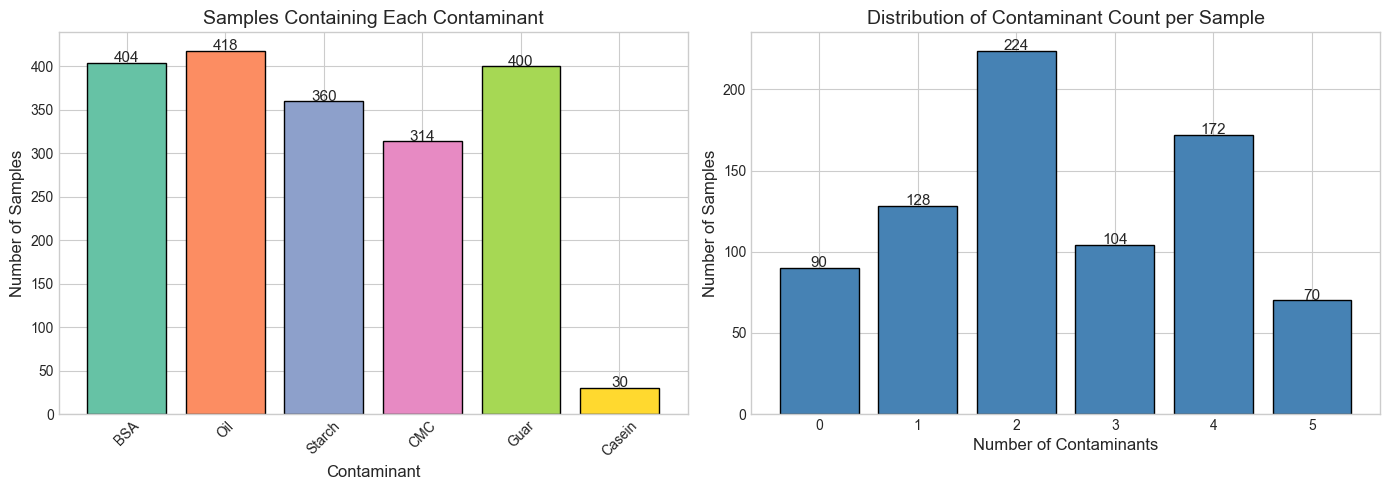

In [8]:
# Contaminant distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Individual contaminant counts
contaminant_counts = contaminant_labels.sum(axis=0)
colors = sns.color_palette('Set2', len(CONTAMINANTS))
bars = axes[0].bar(CONTAMINANTS, contaminant_counts, color=colors, edgecolor='black')
axes[0].set_xlabel('Contaminant', fontsize=12)
axes[0].set_ylabel('Number of Samples', fontsize=12)
axes[0].set_title('Samples Containing Each Contaminant', fontsize=14)
axes[0].tick_params(axis='x', rotation=45)
for bar, count in zip(bars, contaminant_counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 str(int(count)), ha='center', fontsize=11)

# Number of contaminants per sample
n_cont_counts = df['n_contaminants'].value_counts().sort_index()
axes[1].bar(n_cont_counts.index.astype(str), n_cont_counts.values, 
            color='steelblue', edgecolor='black')
axes[1].set_xlabel('Number of Contaminants', fontsize=12)
axes[1].set_ylabel('Number of Samples', fontsize=12)
axes[1].set_title('Distribution of Contaminant Count per Sample', fontsize=14)
for i, (idx, count) in enumerate(n_cont_counts.items()):
    axes[1].text(i, count + 0.5, str(count), ha='center', fontsize=11)

plt.tight_layout()
plt.show()

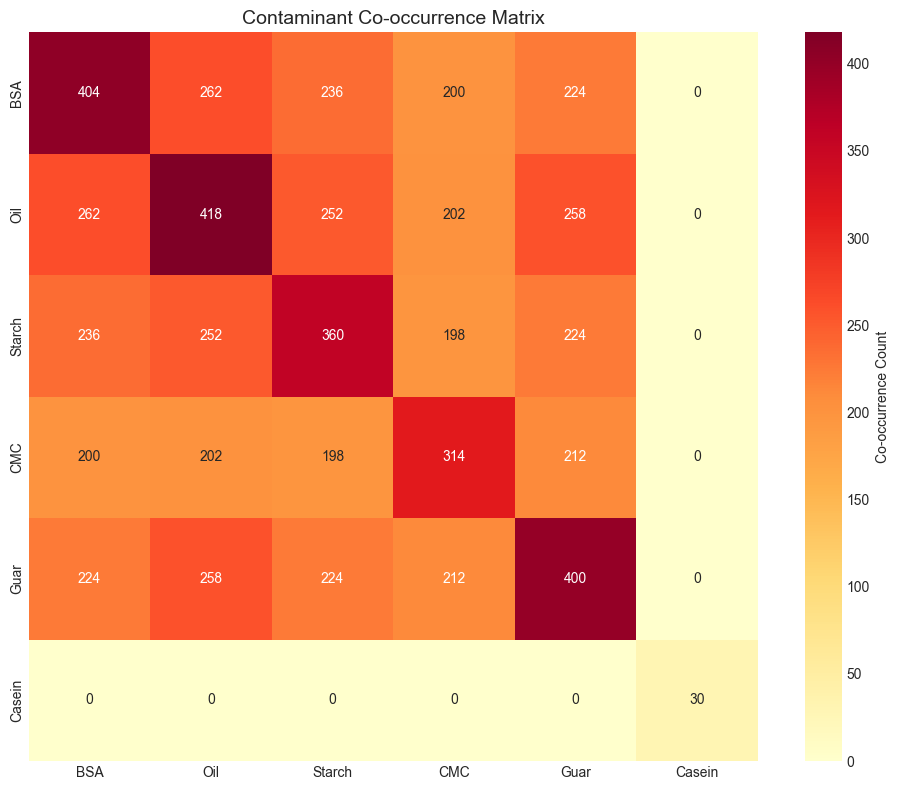


Diagonal values represent total samples with each contaminant.
Off-diagonal values represent samples with both contaminants.


In [9]:
# Contaminant co-occurrence matrix
co_occurrence = contaminant_labels.T @ contaminant_labels

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(co_occurrence, dtype=bool), k=1)
sns.heatmap(co_occurrence, annot=True, fmt='g', cmap='YlOrRd',
            xticklabels=CONTAMINANTS, yticklabels=CONTAMINANTS,
            mask=None, square=True, cbar_kws={'label': 'Co-occurrence Count'})
plt.title('Contaminant Co-occurrence Matrix', fontsize=14)
plt.tight_layout()
plt.show()

print("\nDiagonal values represent total samples with each contaminant.")
print("Off-diagonal values represent samples with both contaminants.")

Plastic Type vs Contamination Status:
              Clean  Contaminated  Total
plastic_type                            
HDPE             24           214    238
LDPE             26           162    188
LLDPE            26           164    190
PP               14           158    172
Total            90           698    788


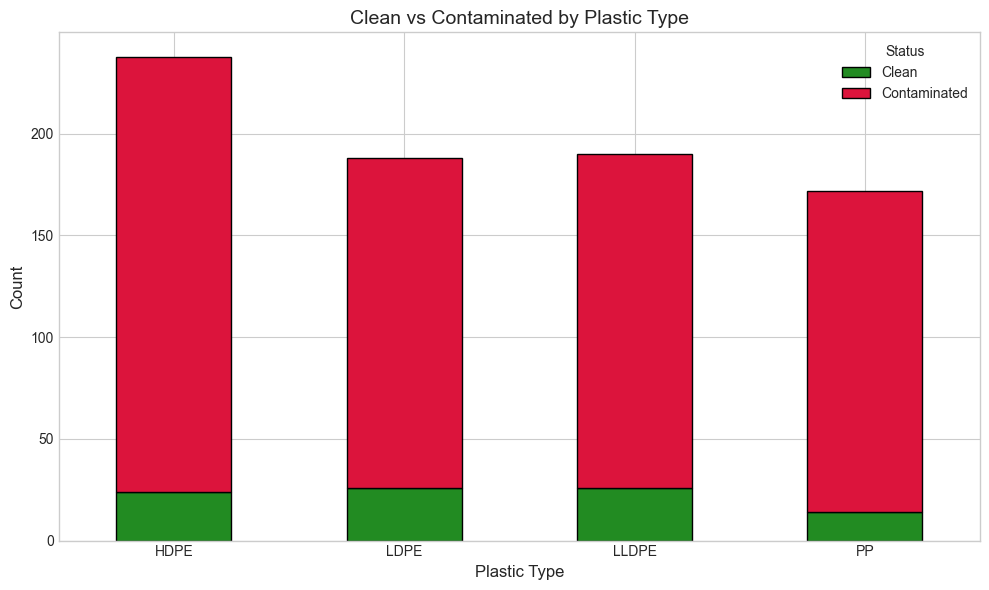

In [10]:
# Cross-tabulation: Plastic type vs contamination status
df['is_contaminated'] = df['n_contaminants'] > 0
cross_tab = pd.crosstab(df['plastic_type'], df['is_contaminated'], 
                        margins=True, margins_name='Total')
cross_tab.columns = ['Clean', 'Contaminated', 'Total']

print("Plastic Type vs Contamination Status:")
print("=" * 50)
print(cross_tab)

# Stacked bar chart
fig, ax = plt.subplots(figsize=(10, 6))
cross_tab_plot = cross_tab.drop('Total').drop('Total', axis=1)
cross_tab_plot.plot(kind='bar', stacked=True, ax=ax, 
                     color=['forestgreen', 'crimson'], edgecolor='black')
ax.set_xlabel('Plastic Type', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Clean vs Contaminated by Plastic Type', fontsize=14)
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Status')
plt.tight_layout()
plt.show()

## 4. Spectral Visualization

C:\Users\Mikey\AppData\Local\Temp\ipykernel_26620\3729345511.py:20: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\Mikey\anaconda3\envs\CMSE\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


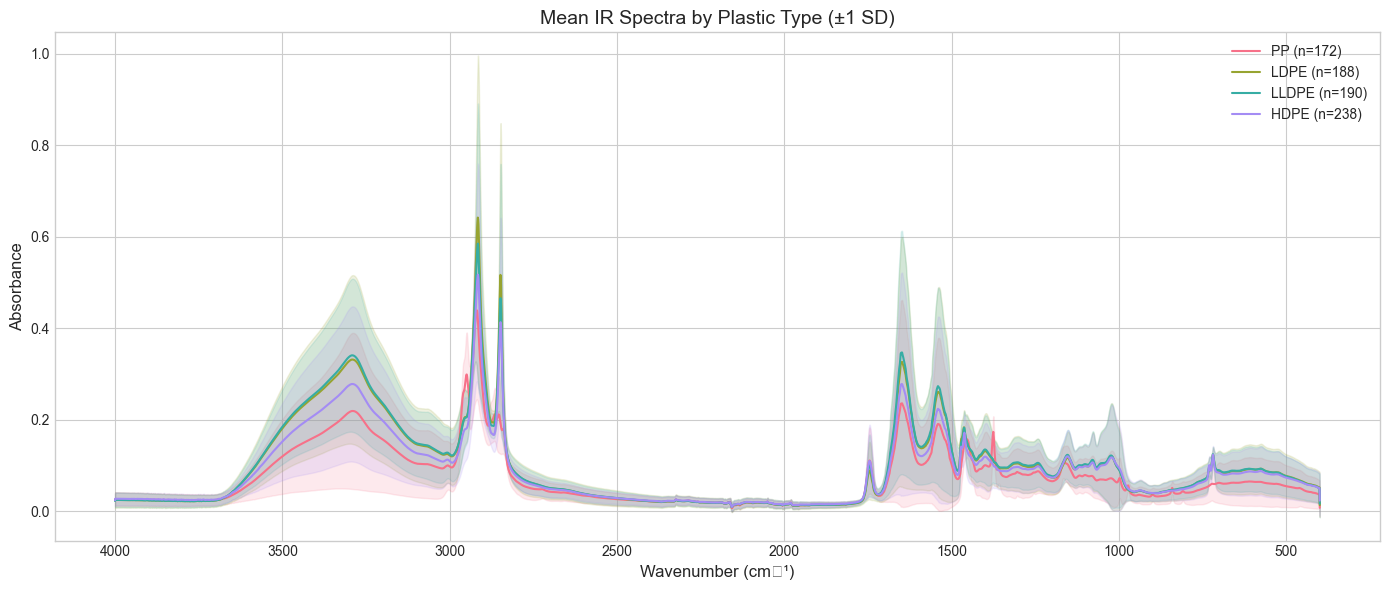

In [11]:
# Mean spectra by plastic type
plt.figure(figsize=(14, 6))

colors = sns.color_palette('husl', len(PLASTIC_TYPES))
for idx, plastic in enumerate(PLASTIC_TYPES):
    mask = np.array(plastic_types) == plastic
    mean_spectrum = spectra[mask].mean(axis=0)
    std_spectrum = spectra[mask].std(axis=0)
    
    plt.plot(wavenumbers, mean_spectrum, label=f'{plastic} (n={mask.sum()})', 
             color=colors[idx], linewidth=1.5)
    plt.fill_between(wavenumbers, mean_spectrum - std_spectrum, 
                     mean_spectrum + std_spectrum, alpha=0.15, color=colors[idx])

plt.xlabel('Wavenumber (cm⁻¹)', fontsize=12)
plt.ylabel('Absorbance', fontsize=12)
plt.title('Mean IR Spectra by Plastic Type (±1 SD)', fontsize=14)
plt.legend(loc='upper right')
plt.gca().invert_xaxis()
plt.tight_layout()
plt.show()

C:\Users\Mikey\AppData\Local\Temp\ipykernel_26620\3134270341.py:22: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.tight_layout()


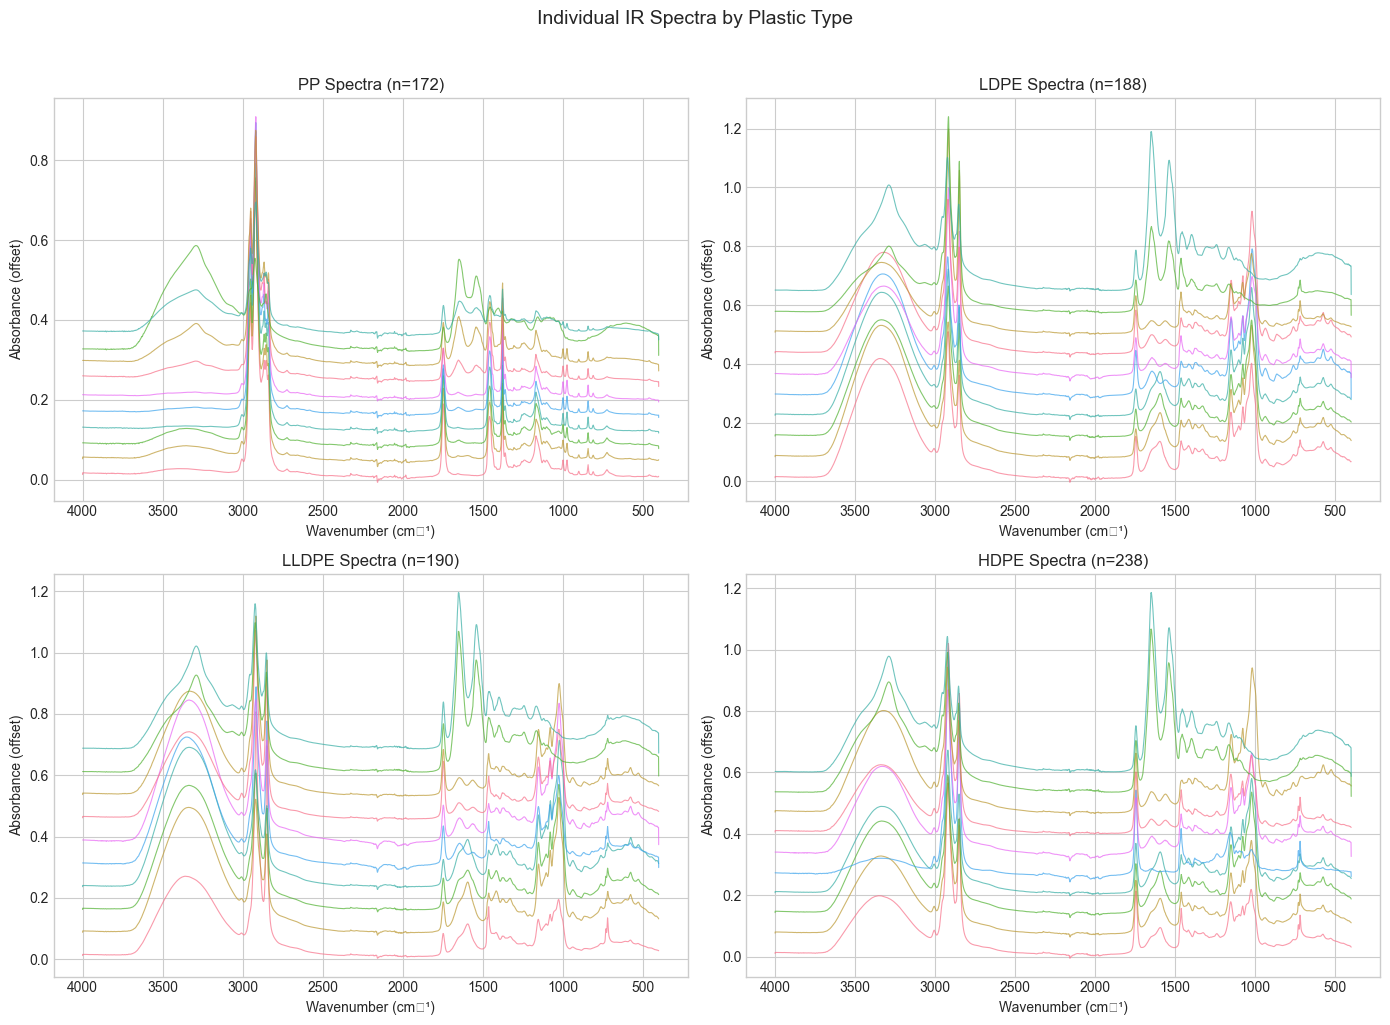

In [12]:
# Individual spectra by plastic type (waterfall plot)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, plastic in enumerate(PLASTIC_TYPES):
    mask = np.array(plastic_types) == plastic
    plastic_spectra = spectra[mask]
    
    # Plot all spectra with offset for visibility
    offset = 0
    for i in range(min(10, len(plastic_spectra))):
        axes[idx].plot(wavenumbers, plastic_spectra[i] + offset, 
                       alpha=0.7, linewidth=0.8)
        offset += 0.05 * (plastic_spectra.max() - plastic_spectra.min())
    
    axes[idx].set_xlabel('Wavenumber (cm⁻¹)')
    axes[idx].set_ylabel('Absorbance (offset)')
    axes[idx].set_title(f'{plastic} Spectra (n={mask.sum()})')
    axes[idx].invert_xaxis()

plt.suptitle('Individual IR Spectra by Plastic Type', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

C:\Users\Mikey\AppData\Local\Temp\ipykernel_26620\1257708015.py:34: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.tight_layout()


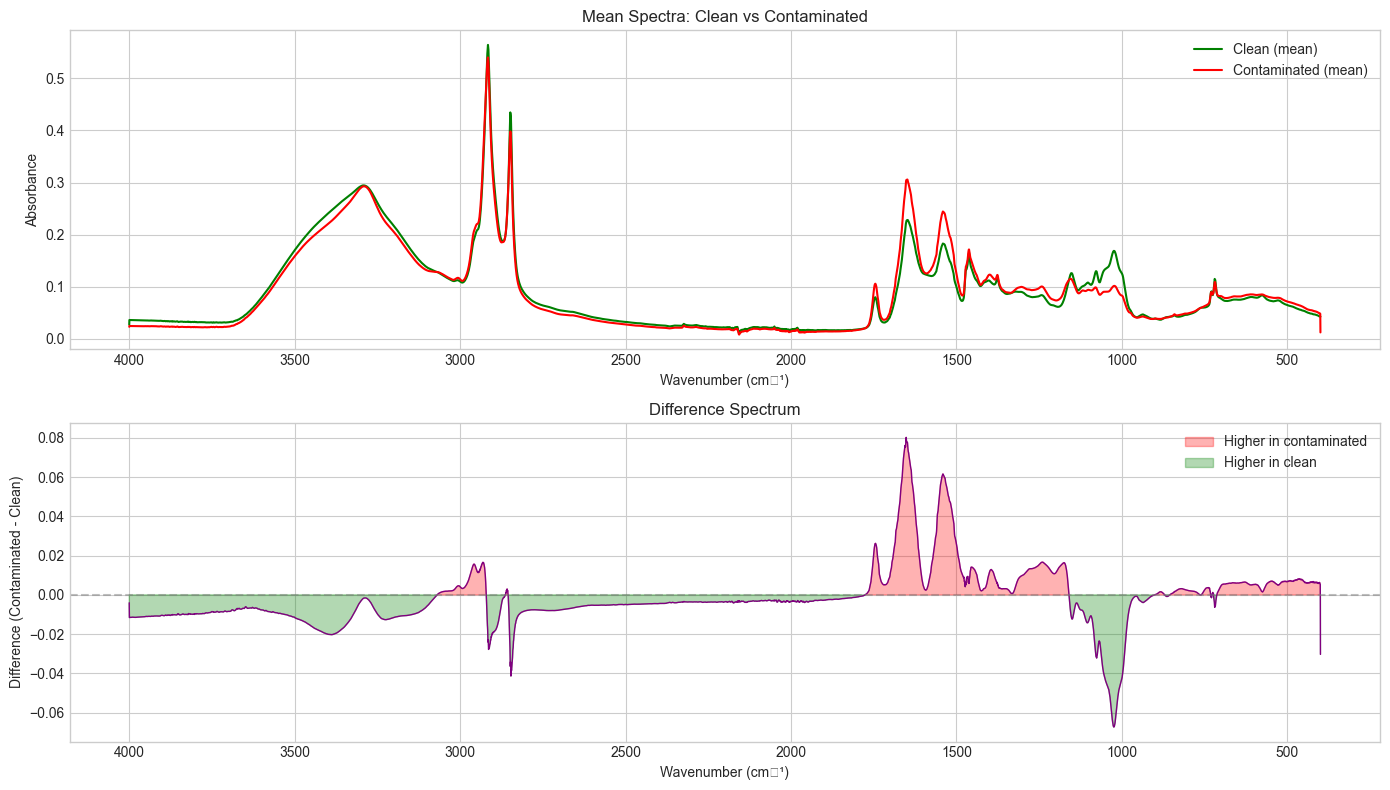

In [13]:
# Difference spectra: Contaminated vs Clean
clean_mask = df['n_contaminants'] == 0
contaminated_mask = df['n_contaminants'] > 0

if clean_mask.sum() > 0 and contaminated_mask.sum() > 0:
    mean_clean = spectra[clean_mask.values].mean(axis=0)
    mean_contaminated = spectra[contaminated_mask.values].mean(axis=0)
    difference = mean_contaminated - mean_clean
    
    fig, axes = plt.subplots(2, 1, figsize=(14, 8))
    
    # Comparison
    axes[0].plot(wavenumbers, mean_clean, label='Clean (mean)', color='green', linewidth=1.5)
    axes[0].plot(wavenumbers, mean_contaminated, label='Contaminated (mean)', color='red', linewidth=1.5)
    axes[0].set_xlabel('Wavenumber (cm⁻¹)')
    axes[0].set_ylabel('Absorbance')
    axes[0].set_title('Mean Spectra: Clean vs Contaminated')
    axes[0].legend()
    axes[0].invert_xaxis()
    
    # Difference spectrum
    axes[1].plot(wavenumbers, difference, color='purple', linewidth=1)
    axes[1].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    axes[1].fill_between(wavenumbers, 0, difference, where=difference > 0, 
                         alpha=0.3, color='red', label='Higher in contaminated')
    axes[1].fill_between(wavenumbers, 0, difference, where=difference < 0, 
                         alpha=0.3, color='green', label='Higher in clean')
    axes[1].set_xlabel('Wavenumber (cm⁻¹)')
    axes[1].set_ylabel('Difference (Contaminated - Clean)')
    axes[1].set_title('Difference Spectrum')
    axes[1].legend()
    axes[1].invert_xaxis()
    
    plt.tight_layout()
    plt.show()
else:
    print("Need both clean and contaminated samples for comparison.")

## 5. Baseline Correction Analysis

C:\Users\Mikey\AppData\Local\Temp\ipykernel_26620\2564350416.py:37: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.tight_layout()


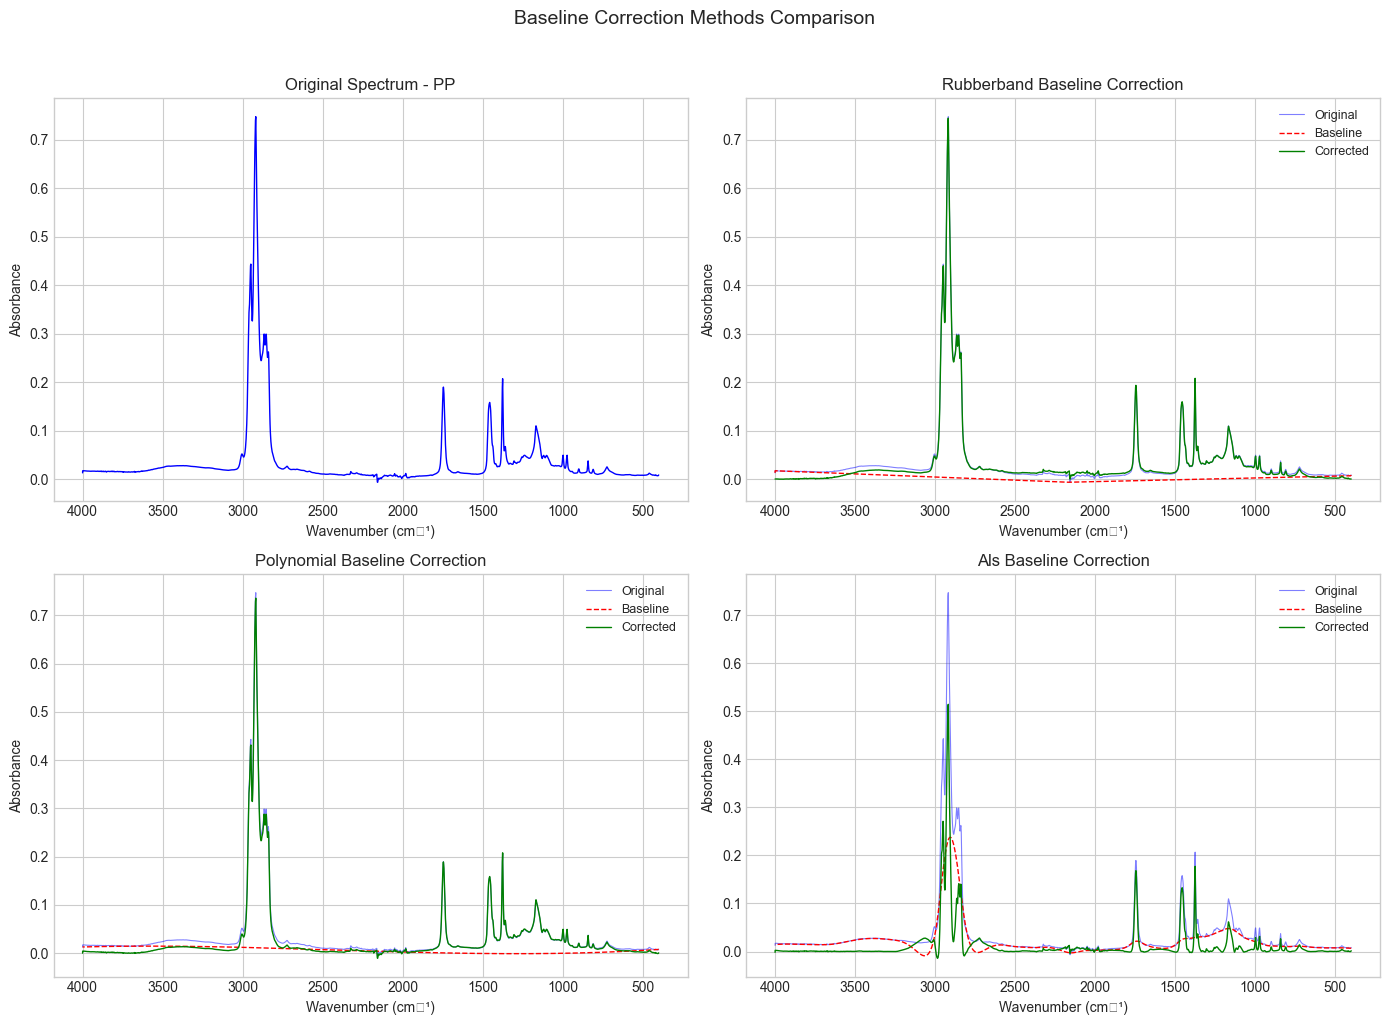

In [14]:
# Compare baseline correction methods on a representative sample
sample_idx = 0  # Use first sample
original = spectra[sample_idx]

methods = ['rubberband', 'polynomial', 'als']
method_params = {
    'rubberband': {},
    'polynomial': {'degree': 3},
    'als': {'lam': 1e6, 'p': 0.01}
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Original
axes[0, 0].plot(wavenumbers, original, 'b-', linewidth=1)
axes[0, 0].set_title(f'Original Spectrum - {plastic_types[sample_idx]}')
axes[0, 0].set_xlabel('Wavenumber (cm⁻¹)')
axes[0, 0].set_ylabel('Absorbance')
axes[0, 0].invert_xaxis()

# Each method
for idx, method in enumerate(methods):
    ax = axes[(idx + 1) // 2, (idx + 1) % 2]
    corrected = baseline_correction(wavenumbers, original, method=method, **method_params[method])
    baseline = original - corrected
    
    ax.plot(wavenumbers, original, 'b-', alpha=0.5, linewidth=0.8, label='Original')
    ax.plot(wavenumbers, baseline, 'r--', linewidth=1, label='Baseline')
    ax.plot(wavenumbers, corrected, 'g-', linewidth=1, label='Corrected')
    ax.set_title(f'{method.capitalize()} Baseline Correction')
    ax.set_xlabel('Wavenumber (cm⁻¹)')
    ax.set_ylabel('Absorbance')
    ax.legend(loc='upper right', fontsize=9)
    ax.invert_xaxis()

plt.suptitle('Baseline Correction Methods Comparison', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [15]:
# Statistics comparison after baseline correction
print("Baseline Correction Statistics Comparison")
print("=" * 70)
print(f"{'Method':<15} {'Min':>12} {'Max':>12} {'Mean':>12} {'Std':>12}")
print("-" * 70)

print(f"{'Original':<15} {original.min():>12.6f} {original.max():>12.6f} "
      f"{original.mean():>12.6f} {original.std():>12.6f}")

for method in methods:
    corrected = baseline_correction(wavenumbers, original, method=method, **method_params[method])
    print(f"{method.capitalize():<15} {corrected.min():>12.6f} {corrected.max():>12.6f} "
          f"{corrected.mean():>12.6f} {corrected.std():>12.6f}")

Baseline Correction Statistics Comparison
Method                   Min          Max         Mean          Std
----------------------------------------------------------------------
Original           -0.006746     0.747256     0.035095     0.074623
Rubberband         -0.000745     0.744175     0.032458     0.074828
Polynomial         -0.010683     0.735882     0.028765     0.074221
Als                -0.014159     0.514752     0.013132     0.043916


## 6. Dimensionality Reduction (PCA)

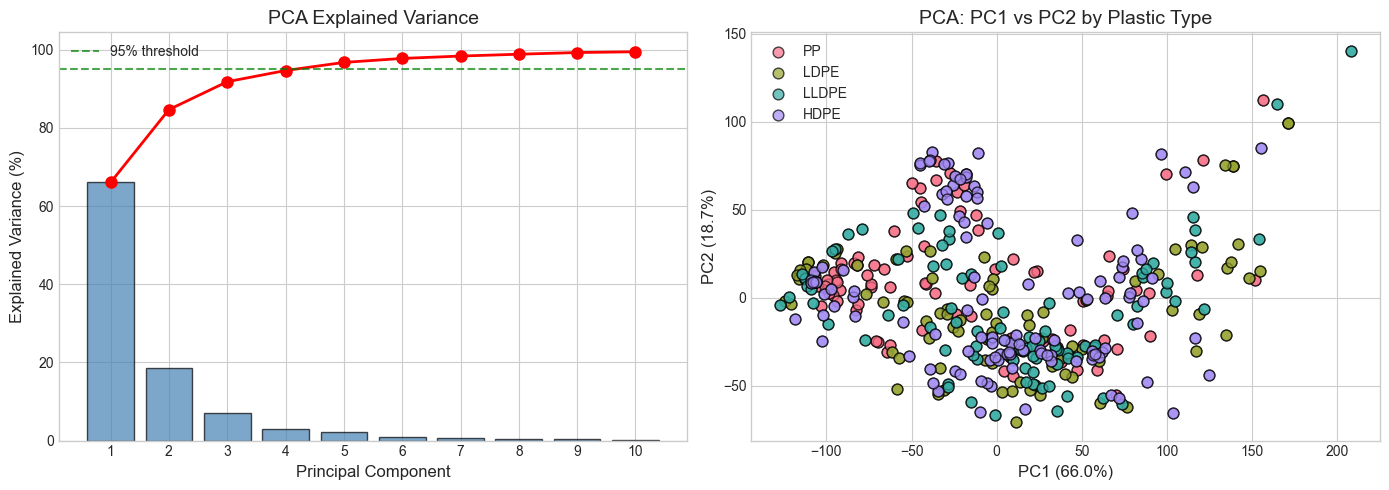


Variance explained by first 5 PCs: 96.8%
Variance explained by first 10 PCs: 99.5%


In [16]:
# Apply PCA to the spectral data
scaler = StandardScaler()
spectra_scaled = scaler.fit_transform(spectra)

pca = PCA(n_components=10)
spectra_pca = pca.fit_transform(spectra_scaled)

# Explained variance
explained_var = pca.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot
axes[0].bar(range(1, 11), explained_var * 100, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].plot(range(1, 11), cumulative_var * 100, 'ro-', linewidth=2, markersize=8)
axes[0].set_xlabel('Principal Component', fontsize=12)
axes[0].set_ylabel('Explained Variance (%)', fontsize=12)
axes[0].set_title('PCA Explained Variance', fontsize=14)
axes[0].set_xticks(range(1, 11))
axes[0].axhline(y=95, color='green', linestyle='--', alpha=0.7, label='95% threshold')
axes[0].legend()

# PC1 vs PC2 scatter plot
colors = sns.color_palette('husl', len(PLASTIC_TYPES))
for idx, plastic in enumerate(PLASTIC_TYPES):
    mask = np.array(plastic_types) == plastic
    axes[1].scatter(spectra_pca[mask, 0], spectra_pca[mask, 1], 
                    c=[colors[idx]], label=plastic, alpha=0.7, s=60, edgecolors='black')

axes[1].set_xlabel(f'PC1 ({explained_var[0]*100:.1f}%)', fontsize=12)
axes[1].set_ylabel(f'PC2 ({explained_var[1]*100:.1f}%)', fontsize=12)
axes[1].set_title('PCA: PC1 vs PC2 by Plastic Type', fontsize=14)
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nVariance explained by first 5 PCs: {cumulative_var[4]*100:.1f}%")
print(f"Variance explained by first 10 PCs: {cumulative_var[9]*100:.1f}%")

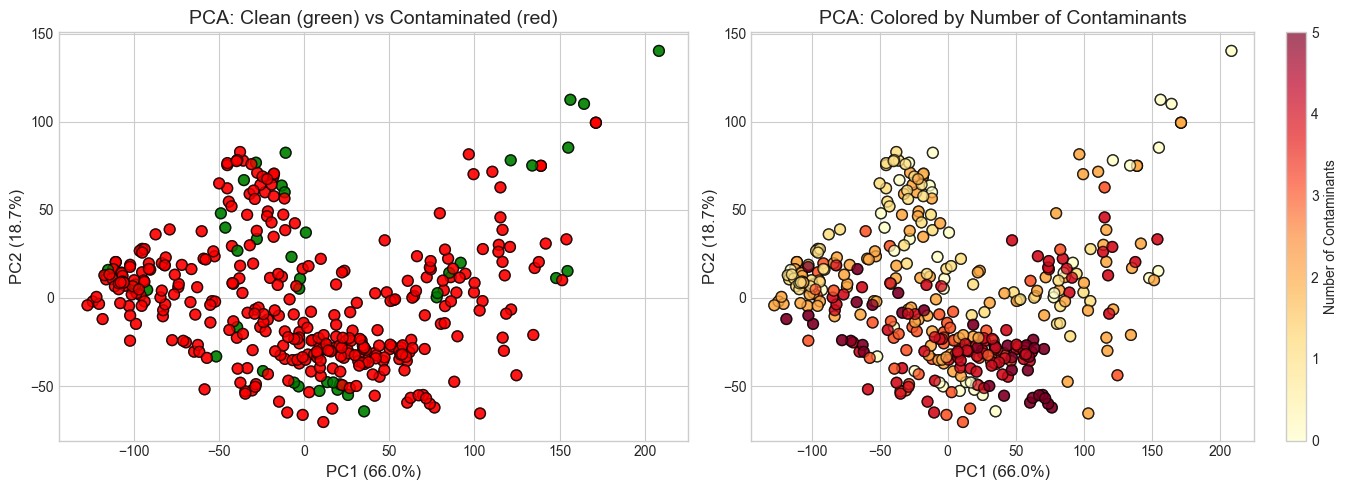

In [17]:
# PCA scatter plots with different colorings
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# By contamination status
colors_cont = ['green' if n == 0 else 'red' for n in df['n_contaminants']]
scatter1 = axes[0].scatter(spectra_pca[:, 0], spectra_pca[:, 1], 
                           c=colors_cont, alpha=0.7, s=60, edgecolors='black')
axes[0].set_xlabel(f'PC1 ({explained_var[0]*100:.1f}%)', fontsize=12)
axes[0].set_ylabel(f'PC2 ({explained_var[1]*100:.1f}%)', fontsize=12)
axes[0].set_title('PCA: Clean (green) vs Contaminated (red)', fontsize=14)

# By number of contaminants
scatter2 = axes[1].scatter(spectra_pca[:, 0], spectra_pca[:, 1], 
                           c=df['n_contaminants'], cmap='YlOrRd', 
                           alpha=0.7, s=60, edgecolors='black')
plt.colorbar(scatter2, ax=axes[1], label='Number of Contaminants')
axes[1].set_xlabel(f'PC1 ({explained_var[0]*100:.1f}%)', fontsize=12)
axes[1].set_ylabel(f'PC2 ({explained_var[1]*100:.1f}%)', fontsize=12)
axes[1].set_title('PCA: Colored by Number of Contaminants', fontsize=14)

plt.tight_layout()
plt.show()

C:\Users\Mikey\AppData\Local\Temp\ipykernel_26620\4001798765.py:20: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\Mikey\anaconda3\envs\CMSE\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


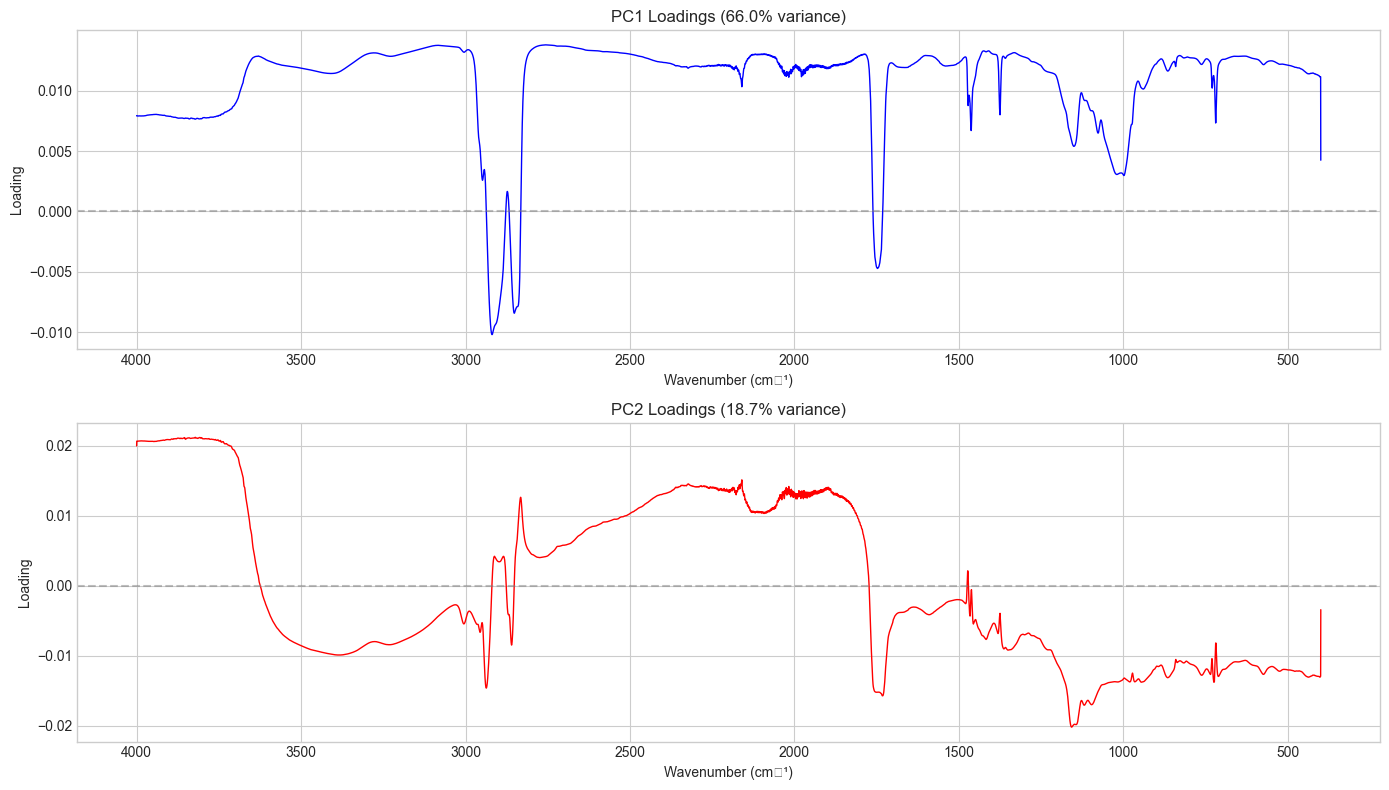

In [18]:
# PCA loadings - which wavenumbers contribute most to each PC
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# PC1 loadings
axes[0].plot(wavenumbers, pca.components_[0], 'b-', linewidth=1)
axes[0].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[0].set_xlabel('Wavenumber (cm⁻¹)')
axes[0].set_ylabel('Loading')
axes[0].set_title(f'PC1 Loadings ({explained_var[0]*100:.1f}% variance)')
axes[0].invert_xaxis()

# PC2 loadings
axes[1].plot(wavenumbers, pca.components_[1], 'r-', linewidth=1)
axes[1].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Wavenumber (cm⁻¹)')
axes[1].set_ylabel('Loading')
axes[1].set_title(f'PC2 Loadings ({explained_var[1]*100:.1f}% variance)')
axes[1].invert_xaxis()

plt.tight_layout()
plt.show()

## 7. Feature Analysis

C:\Users\Mikey\AppData\Local\Temp\ipykernel_26620\1159520468.py:23: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.tight_layout()


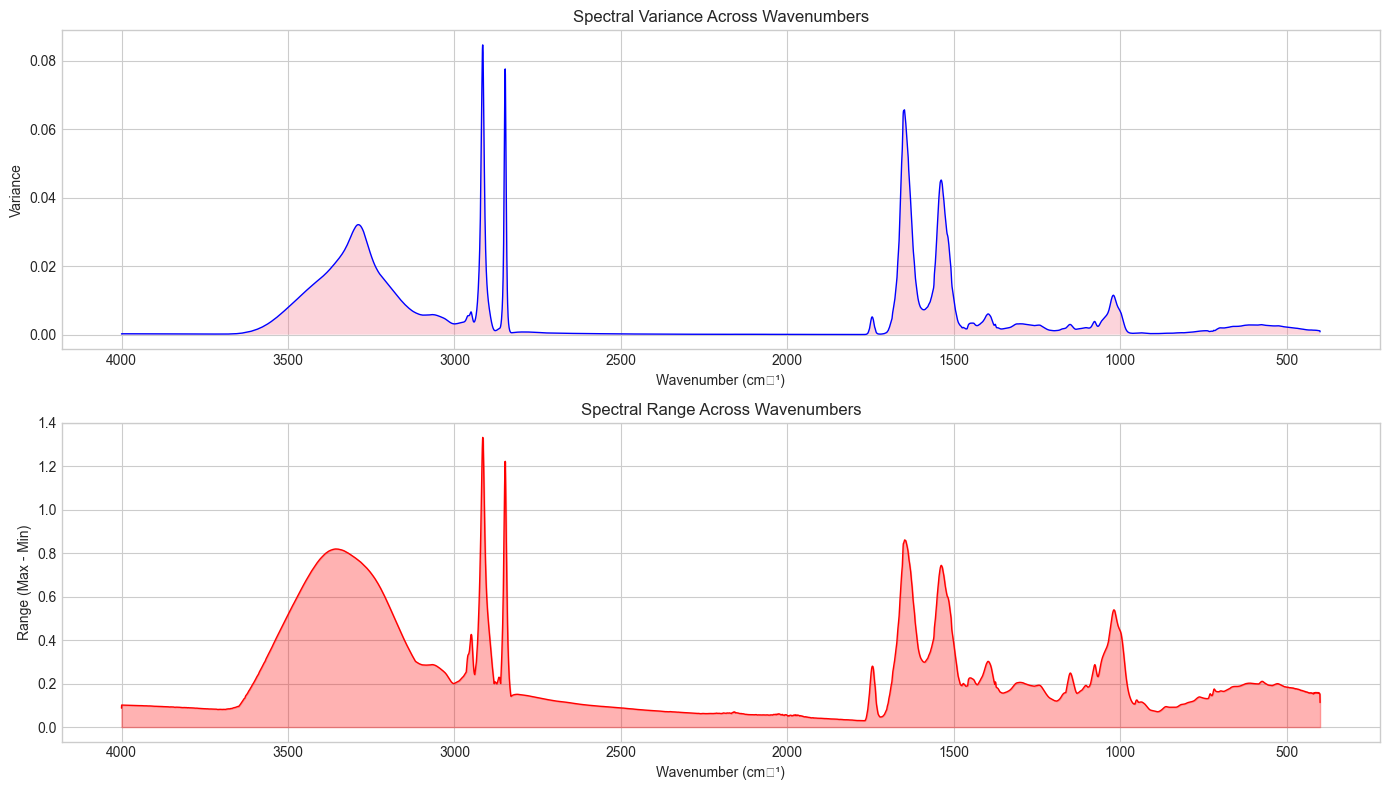


Top 5 most variable wavenumber positions:
  2914.9 cm⁻¹ (variance: 0.084673)
  2915.4 cm⁻¹ (variance: 0.084496)
  2914.4 cm⁻¹ (variance: 0.083952)
  2915.9 cm⁻¹ (variance: 0.083441)
  2914.0 cm⁻¹ (variance: 0.082388)


In [19]:
# Identify key spectral regions - variance analysis
spectral_variance = spectra.var(axis=0)
spectral_range = spectra.max(axis=0) - spectra.min(axis=0)

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Variance across wavenumbers
axes[0].plot(wavenumbers, spectral_variance, 'b-', linewidth=1)
axes[0].fill_between(wavenumbers, 0, spectral_variance, alpha=0.3)
axes[0].set_xlabel('Wavenumber (cm⁻¹)')
axes[0].set_ylabel('Variance')
axes[0].set_title('Spectral Variance Across Wavenumbers')
axes[0].invert_xaxis()

# Range across wavenumbers
axes[1].plot(wavenumbers, spectral_range, 'r-', linewidth=1)
axes[1].fill_between(wavenumbers, 0, spectral_range, alpha=0.3, color='red')
axes[1].set_xlabel('Wavenumber (cm⁻¹)')
axes[1].set_ylabel('Range (Max - Min)')
axes[1].set_title('Spectral Range Across Wavenumbers')
axes[1].invert_xaxis()

plt.tight_layout()
plt.show()

# Find top 5 most variable wavenumbers
top_variance_idx = np.argsort(spectral_variance)[-5:][::-1]
print("\nTop 5 most variable wavenumber positions:")
for idx in top_variance_idx:
    print(f"  {wavenumbers[idx]:.1f} cm⁻¹ (variance: {spectral_variance[idx]:.6f})")

C:\Users\Mikey\AppData\Local\Temp\ipykernel_26620\2117507188.py:26: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.tight_layout()


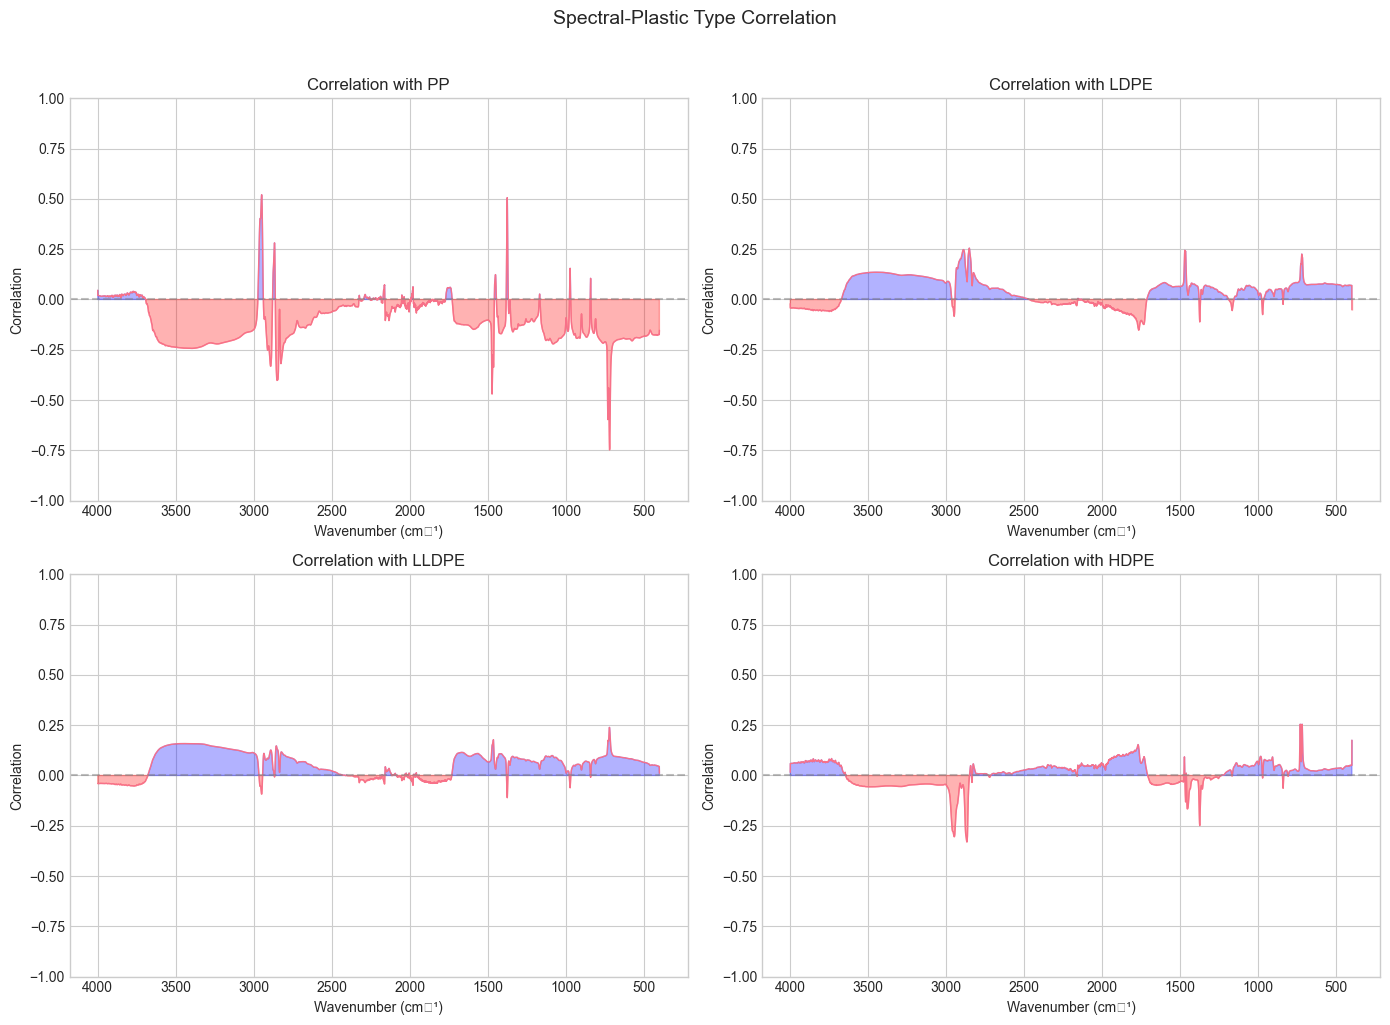

In [20]:
# Correlation between spectral features and labels
# Calculate correlation between each wavenumber and plastic type (using one-hot encoding)

correlations = {}
for i, plastic in enumerate(PLASTIC_TYPES):
    corr = np.array([np.corrcoef(spectra[:, j], plastic_labels[:, i])[0, 1] 
                     for j in range(spectra.shape[1])])
    correlations[plastic] = corr

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, plastic in enumerate(PLASTIC_TYPES):
    corr = correlations[plastic]
    axes[idx].plot(wavenumbers, corr, linewidth=1)
    axes[idx].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    axes[idx].fill_between(wavenumbers, 0, corr, where=corr > 0, alpha=0.3, color='blue')
    axes[idx].fill_between(wavenumbers, 0, corr, where=corr < 0, alpha=0.3, color='red')
    axes[idx].set_xlabel('Wavenumber (cm⁻¹)')
    axes[idx].set_ylabel('Correlation')
    axes[idx].set_title(f'Correlation with {plastic}')
    axes[idx].invert_xaxis()
    axes[idx].set_ylim(-1, 1)

plt.suptitle('Spectral-Plastic Type Correlation', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [21]:
# Summary statistics table
print("\n" + "=" * 70)
print("EXPLORATORY DATA ANALYSIS SUMMARY")
print("=" * 70)

print(f"\n📊 Dataset Overview:")
print(f"   • Total samples: {len(df)}")
print(f"   • Spectral points: {len(wavenumbers)}")
print(f"   • Wavenumber range: {wavenumbers.min():.1f} - {wavenumbers.max():.1f} cm⁻¹")

print(f"\n🧪 Plastic Types:")
for plastic in PLASTIC_TYPES:
    count = (df['plastic_type'] == plastic).sum()
    print(f"   • {plastic}: {count} samples ({count/len(df)*100:.1f}%)")

print(f"\n🔬 Contamination Status:")
print(f"   • Clean samples: {(df['n_contaminants'] == 0).sum()}")
print(f"   • Contaminated samples: {(df['n_contaminants'] > 0).sum()}")

print(f"\n📈 PCA Results:")
print(f"   • PC1 explains: {explained_var[0]*100:.1f}% variance")
print(f"   • PC1+PC2 explain: {cumulative_var[1]*100:.1f}% variance")
print(f"   • First 5 PCs explain: {cumulative_var[4]*100:.1f}% variance")

print("\n" + "=" * 70)


EXPLORATORY DATA ANALYSIS SUMMARY

📊 Dataset Overview:
   • Total samples: 788
   • Spectral points: 7469
   • Wavenumber range: 399.7 - 4000.2 cm⁻¹

🧪 Plastic Types:
   • PP: 172 samples (21.8%)
   • LDPE: 188 samples (23.9%)
   • LLDPE: 190 samples (24.1%)
   • HDPE: 238 samples (30.2%)

🔬 Contamination Status:
   • Clean samples: 90
   • Contaminated samples: 698

📈 PCA Results:
   • PC1 explains: 66.0% variance
   • PC1+PC2 explain: 84.7% variance
   • First 5 PCs explain: 96.8% variance

